### Redimensionnement intelligent par Seam Carving (scaling up)

Ce notebook met en œuvre un algorithme de **scaling up basé sur le Seam Carving**, 
permettant d'agrandir une image sans distorsion importante des objets visuellement saillants.

L’objectif est de tester le comportement du Seam Carving pour :
- **dupliquer les seams** à faible énergie (au lieu de les supprimer),
- observer comment l’image s’adapte à une augmentation de résolution.

Exemples visuels à l'appui pour analyser la qualité de l’agrandissement.


In [1]:
# Import necessary libraries

# For the seam carving algorithm
import cv2 # type: ignore
import numpy as np
import matplotlib.pyplot as plt

#For the entropy energy map
from skimage.filters import rank
from skimage.morphology import disk

# For the HoG energy map
from skimage.feature import hog
from skimage.color   import rgb2gray

# To use the Numba JIT compiler
from numba import njit

# To use joblib for parallel processing
from joblib import Parallel, delayed

In [2]:
# Load the image
desert = cv2.imread('../dataset/desert.jpg')
beach = cv2.imread('../dataset/kodim16.png')

from class_SeamCarver import SeamCarver

print("Original Image of desert shape:", desert.shape)
print("Original image of beach shape:", beach.shape)

Original Image of desert shape: (384, 512, 3)
Original image of beach shape: (512, 768, 3)


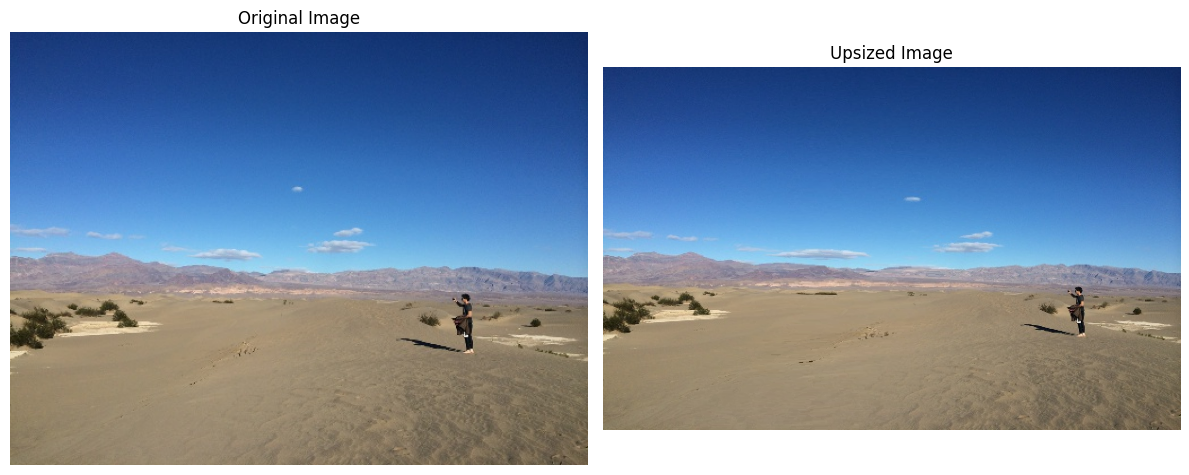

Original Image Shape: (384, 512, 3)
Upsized ImageShape: (384, 612, 3)


In [3]:
# 1) Create a SeamCarver object
sc = SeamCarver(desert)

# 2) Define the number of seams to remove
num_seams = 100

# 3) Perform seam carving
history = sc.collect_seams(num_seams, method='l1',orientation='vertical')
carved_image = sc.upsize(desert, num_seams, method='l1',orientation='vertical') 

# 4) Display the original and carved images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(desert, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(carved_image.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title('Upsized Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Original Image Shape:", desert.shape)
print("Upsized ImageShape:", carved_image.shape)

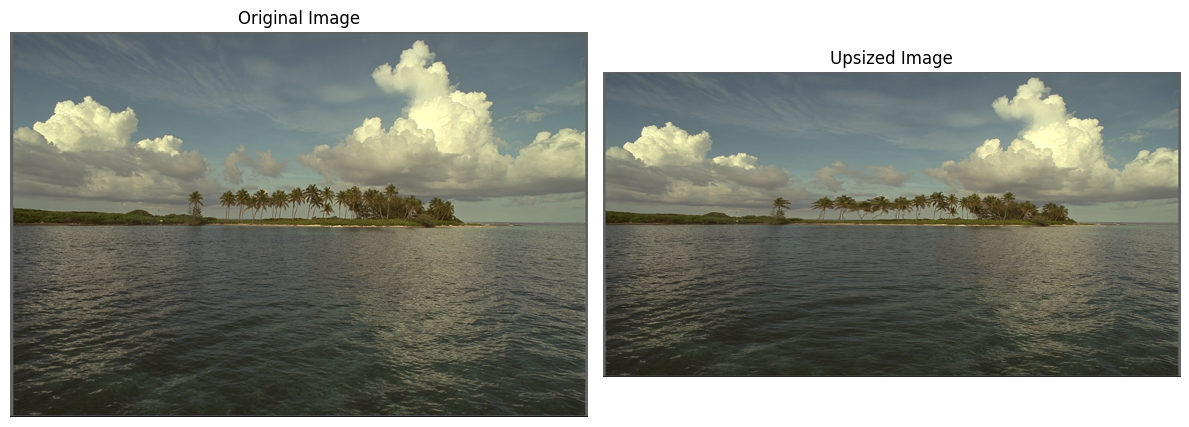

Original Image Shape: (512, 768, 3)
Upsized ImageShape: (512, 968, 3)


In [4]:
# 1) Create a SeamCarver object
sc = SeamCarver(beach)

# 2) Define the number of seams to remove
num_seams = 200

# 3) Perform seam carving
history = sc.collect_seams(num_seams, method='l1',orientation='vertical')
carved_image = sc.upsize(beach, num_seams, method='l1',orientation='vertical') 

# 4) Display the original and carved images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(beach, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(carved_image.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title('Upsized Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Original Image Shape:", beach.shape)
print("Upsized ImageShape:", carved_image.shape)